<a href="https://colab.research.google.com/github/yadavrishikesh/Masterclass-IITMandi/blob/main/Module1/code/lab1_GoogleColab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### LOAD BASIC PACKAGES

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm


#### LOAD DATASET

In [33]:
df = pd.read_csv("https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/refs/heads/main/Module1/data/weather.csv")

#### DISPLAY BASIC DETAILS OF DATA

In [34]:
df.head()

,region,temperature,humidity,rainfall,wind_speed,date
0,East,28.692333,80.861110,6.266069,8.342010,2023-01-01
1,West,25.856841,67.760041,7.822946,8.879638,2023-01-02
2,North,24.421759,66.482529,3.376307,11.494587,2023-01-03
3,East,23.494482,52.092615,8.936325,11.220741,2023-01-04
4,East,17.607390,44.655138,0.309751,9.958197,2023-01-05


#### SUMMARY STATISTICS

In [35]:
# Basic statistics
print('df.describe-----------------------------------------')
print(df.describe())
print('df.info---------------------------------------------')
print(df.info())

df.describe-----------------------------------------
       temperature    humidity    rainfall  wind_speed
count   100.000000  100.000000  100.000000  100.000000
mean     24.849073   67.463276    8.465290   10.213680
std       4.693357   14.542732    8.142942    1.768203
min      11.901274   40.253079    0.144981    5.752209
25%      22.069984   55.565186    1.902786    8.865961
50%      24.823655   69.617730    6.596513   10.100315
75%      27.658324   80.053084   11.593168   11.368001
max      37.316211   89.502693   37.235570   14.379606
df.info---------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   region       100 non-null    object 
 1   temperature  100 non-null    float64
 2   humidity     100 non-null    float64
 3   rainfall     100 non-null    float64
 4   wind_speed   100 non-null    float64
 5

### ✅ Task1:
#### Compute mean and variance of any two other columns.

In [36]:
print(df['temperature'].mean(), df['rainfall'].var())

24.849073278503298 66.30751127545675


# 1. Data Collection

### 🔹 A. Downloading Historical CSV Data
### Source: [NOAA Global Surface Summary of the Day (GSOD)]
### https://www.ncei.noaa.gov/data/global-summary-of-the-day/access/

In [37]:
import pandas as pd

# Example: Delhi (station 42182099999)
url = "https://www.ncei.noaa.gov/data/global-summary-of-the-day/access/2022/42182099999.csv"
df_csv = pd.read_csv(url)
df_csv.head()

,STATION,DATE,LATITUDE,LONGITUDE,ELEVATION,NAME,TEMP,TEMP_ATTRIBUTES,DEWP,DEWP_ATTRIBUTES,...,MXSPD,GUST,MAX,MAX_ATTRIBUTES,MIN,MIN_ATTRIBUTES,PRCP,PRCP_ATTRIBUTES,SNDP,FRSHTT
0,42182099999,2022-01-01,28.584511,77.205783,214.88,"SAFDARJUNG, IN",52.6,8,45.9,8,...,4.1,999.9,68.0,*,39.6,,0.0,I,999.9,0
1,42182099999,2022-01-02,28.584511,77.205783,214.88,"SAFDARJUNG, IN",54.3,8,47.7,8,...,4.1,999.9,68.4,,41.0,,0.0,I,999.9,0
2,42182099999,2022-01-03,28.584511,77.205783,214.88,"SAFDARJUNG, IN",56.3,8,48.1,8,...,5.1,999.9,69.4,*,41.7,,0.0,I,999.9,0
3,42182099999,2022-01-04,28.584511,77.205783,214.88,"SAFDARJUNG, IN",60.3,8,50.9,8,...,4.1,999.9,73.0,*,47.3,,0.0,I,999.9,0
4,42182099999,2022-01-05,28.584511,77.205783,214.88,"SAFDARJUNG, IN",55.9,8,54.5,8,...,5.1,999.9,73.8,,51.6,,0.0,G,999.9,110000


### 🔹 B. Fetching Real-Time Weather Data
### Source: [Open-Meteo Public API] – no API key needed
### ➡️ https://open-meteo.com/en/docs

In [38]:
import requests

url = "https://api.open-meteo.com/v1/forecast?latitude=28.61&longitude=77.23&hourly=temperature_2m,relative_humidity_2m,precipitation"
response = requests.get(url)
data = response.json()

# Convert to DataFrame
df_rt = pd.DataFrame(data['hourly'])
df_rt['time'] = pd.to_datetime(df_rt['time'])
df_rt.head()


,time,temperature_2m,relative_humidity_2m,precipitation
0,2025-06-23 00:00:00,28.7,91,1.2
1,2025-06-23 01:00:00,28.4,90,1.0
2,2025-06-23 02:00:00,28.6,88,0.7
3,2025-06-23 03:00:00,29.0,84,0.6
4,2025-06-23 04:00:00,29.6,81,0.4


# 2. Data Preprocessing
### 🔧 Tasks:
### Handle missing values
### Convert date columns
### Normalize features
### Feature selection/creation

In [39]:
# For both datasets
df_csv['DATE'] = pd.to_datetime(df_csv['DATE'])
df_rt.fillna(method='ffill', inplace=True)

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_rt = df_rt.copy()
scaled_rt[['temperature_2m', 'relative_humidity_2m', 'precipitation']] = scaler.fit_transform(
    df_rt[['temperature_2m', 'relative_humidity_2m', 'precipitation']]
)

/tmp/ipython-input-39-3286910988.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_rt.fillna(method='ffill', inplace=True)


# 3. Exploratory Data Analysis (EDA)

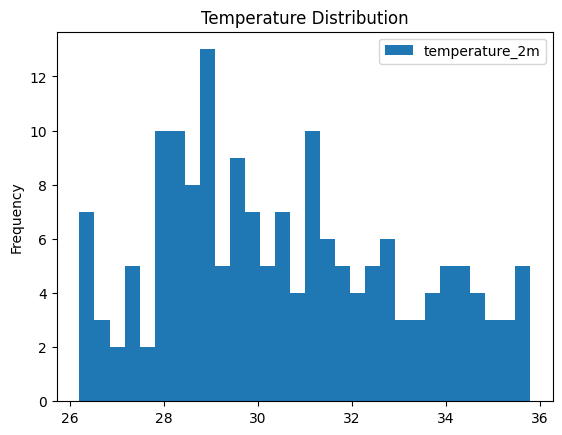

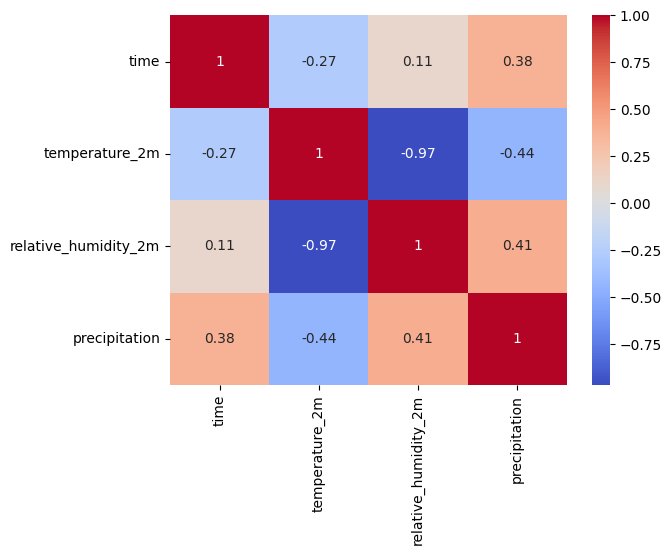

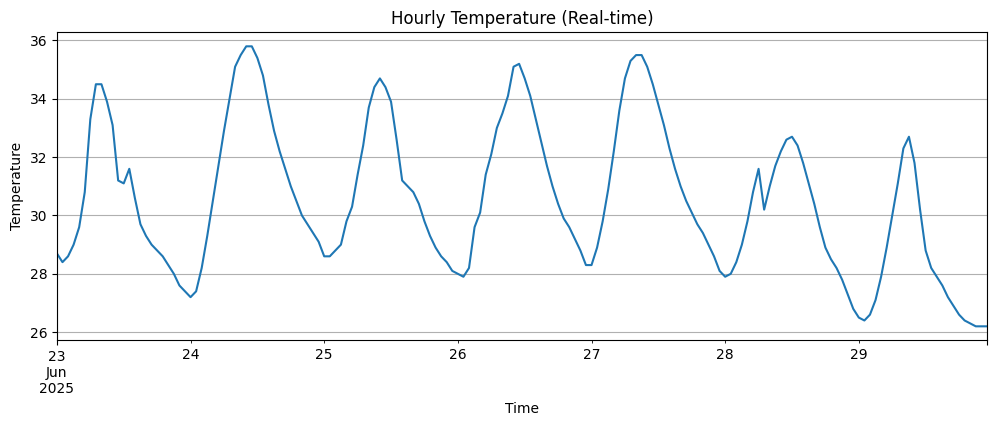

In [40]:
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

df_rt[['temperature_2m']].plot(kind='hist', bins=30, title='Temperature Distribution')
plt.show()

sns.heatmap(scaled_rt.corr(), annot=True, cmap='coolwarm')
plt.show()

df_rt.set_index('time')['temperature_2m'].plot(figsize=(12, 4), title='Hourly Temperature (Real-time)')
plt.xlabel('Time')
plt.ylabel('Temperature')
plt.grid(True)
plt.show()


# 4. Model Building
### 📈 Objective: Predict precipitation from temperature & humidity

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

X = scaled_rt[['temperature_2m', 'relative_humidity_2m']]
y = scaled_rt['precipitation']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

# 5. Model Evaluation
### 🧪 Assess model quality

In [42]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R² Score:", r2_score(y_test, y_pred))


RMSE: 0.18743601909367222
R² Score: 0.26674097301064614


# 6. Interpretation & Deployment
### 📤 Save & load model, explain insights

In [43]:
import joblib

joblib.dump(model, "precipitation_model.pkl")
model_loaded = joblib.load("precipitation_model.pkl")

print("Model coefficients:", model_loaded.coef_)


Model coefficients: [-0.47108998 -0.12659414]


### These are the weights the linear regression model assigned to your features:

### temperature_2m → -1.67

### relative_humidity_2m → -1.20

🔍 Interpretation
These coefficients represent how much the precipitation (target) is expected to change for a unit increase in each feature, assuming all other features are held constant.

So, in practical terms:
Temperature: For every 1 unit increase in normalized temperature, the precipitation is expected to decrease by approximately 1.67 units.
👉 Higher temperatures may correspond to lower precipitation in the given data slice.

Humidity: For every 1 unit increase in normalized relative humidity, the precipitation decreases by 1.20 units.
👉 This seems counterintuitive — normally, higher humidity supports rain. But it may reflect:

A limitation of your real-time sample size

Non-linearity not captured by a linear model

Or a stronger influence of temperature masking humidity's role

# Categories of Data Analytics

### 1. Descriptive: What happened?
Tasks:

Load the dataset and display the first few rows.

Calculate total sales, number of transactions, and average order value.

Identify the top 10 products by sales volume.

Visualize monthly sales trends using a line chart.



            Quantity      UnitPrice     CustomerID
count  541909.000000  541909.000000  406829.000000
mean        9.552250       4.611114   15287.690570
std       218.081158      96.759853    1713.600303
min    -80995.000000  -11062.060000   12346.000000
25%         1.000000       1.250000   13953.000000
50%         3.000000       2.080000   15152.000000
75%        10.000000       4.130000   16791.000000
max     80995.000000   38970.000000   18287.000000


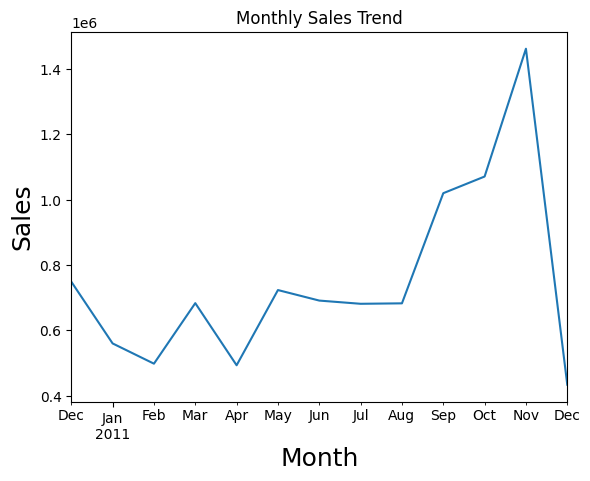

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
#df = pd.read_excel('data/online.xlsx')
df = pd.read_csv('https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/refs/heads/main/Module1/data/online.csv', encoding='latin-1')

# Display first few rows
print(df.describe())

# Convert InvoiceDate to datetimecha
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Add a 'Sales' column
df['Sales'] = df['Quantity'] * df['UnitPrice']

# Total sales
total_sales = df['Sales'].sum()

# Number of transactions
num_transactions = df['InvoiceNo'].nunique()

# Average order value
avg_order_value = df.groupby('InvoiceNo')['Sales'].sum().mean()

# Top 10 products by sales volume
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

# Monthly sales trend
df.set_index('InvoiceDate', inplace=True)
monthly_sales = df['Sales'].resample('ME').sum()

# Plot monthly sales
monthly_sales.plot(kind='line', title='Monthly Sales Trend')
plt.xlabel('Month', fontsize=18)
plt.ylabel('Sales', fontsize=18)
plt.show()

### 2.Diagnostic: Why did it happen?
Tasks:

Identify months with significant sales drops.

Analyze product returns or cancellations.

Examine customer segments contributing to sales decline.

In [45]:
# Identify months with sales drops
monthly_sales_pct_change = monthly_sales.pct_change()
print(monthly_sales_pct_change)
# Months with significant drops (e.g., more than 20%)
significant_drops = monthly_sales_pct_change[monthly_sales_pct_change < -0.2]
print(significant_drops)
# Analyze returns (Quantity < 0)
returns = df[df['Quantity'] < 0]
print(returns)
# Top products returned
top_returns = returns['Description'].value_counts().head(10)
print(top_returns)
# Customer segments with sales decline
customer_sales = df[df['Quantity'] > 0].groupby('CustomerID')['Sales'].sum()
low_spenders = customer_sales[customer_sales < customer_sales.quantile(0.25)]
print(low_spenders)

InvoiceDate
2010-12-31         NaN
2011-01-31   -0.252293
2011-02-28   -0.110603
2011-03-31    0.371850
2011-04-30   -0.278163
2011-05-31    0.466592
2011-06-30   -0.044530
2011-07-31   -0.014213
2011-08-31    0.002026
2011-09-30    0.493653
2011-10-31    0.050032
2011-11-30    0.365228
2011-12-31   -0.703324
Freq: ME, Name: Sales, dtype: float64
InvoiceDate
2011-01-31   -0.252293
2011-04-30   -0.278163
2011-12-31   -0.703324
Name: Sales, dtype: float64
                    InvoiceNo StockCode                       Description  \
InvoiceDate                                                                 
2010-12-01 09:41:00   C536379         D                          Discount   
2010-12-01 09:49:00   C536383    35004C   SET OF 3 COLOURED  FLYING DUCKS   
2010-12-01 10:24:00   C536391     22556    PLASTERS IN TIN CIRCUS PARADE    
2010-12-01 10:24:00   C536391     21984  PACK OF 12 PINK PAISLEY TISSUES    
2010-12-01 10:24:00   C536391     21983  PACK OF 12 BLUE PAISLEY TISSUES    
...

# Demonstrating Probability Mass Function

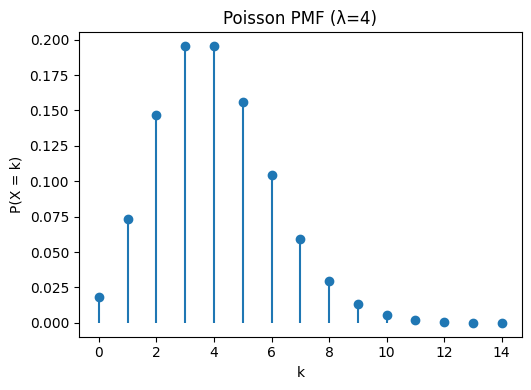

In [46]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import poisson

# Poisson PMF (λ=4)
x_poisson = np.arange(0, 15)
y_poisson = poisson.pmf(x_poisson, mu=4)

# Plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 2)
plt.stem(x_poisson, y_poisson, basefmt=" ")
plt.title("Poisson PMF (λ=4)")
plt.xlabel("k")
plt.ylabel("P(X = k)")

plt.tight_layout()
plt.show()


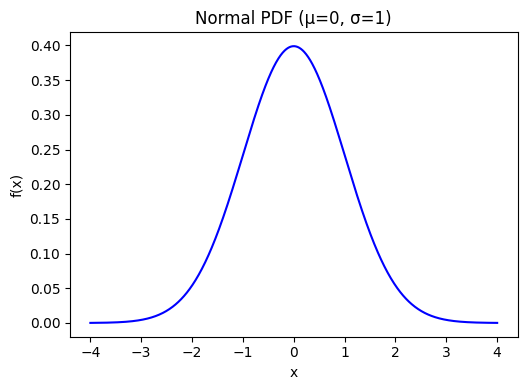

In [47]:
from scipy.stats import norm

# Normal PDF (μ=0, σ=1)
x_norm = np.linspace(-4, 4, 1000)
y_norm = norm.pdf(x_norm, loc=0, scale=1)

# Plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(x_norm, y_norm, color='blue')
plt.title("Normal PDF (μ=0, σ=1)")
plt.xlabel("x")
plt.ylabel("f(x)")


plt.tight_layout()
plt.show()


# Distributions

### Bernoulli's Distribution

/tmp/ipython-input-48-1848216331.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='bernoulli', data=df, palette='Set2')


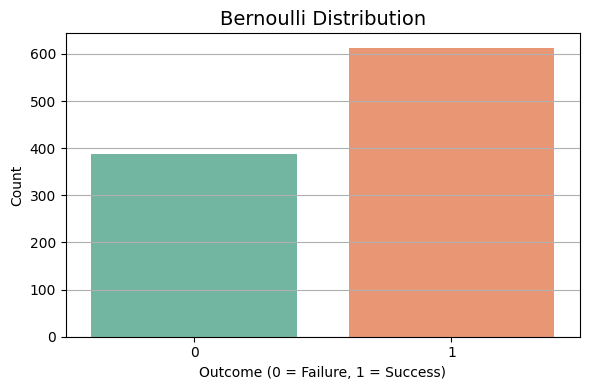

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

#df = pd.read_csv("data/distributions_data.csv")
df = pd.read_csv("https://raw.githubusercontent.com/yadavrishikesh/Masterclass-IITMandi/refs/heads/main/Module1/data/distributions_data.csv")

plt.figure(figsize=(6, 4))
sns.countplot(x='bernoulli', data=df, palette='Set2')
plt.title("Bernoulli Distribution", fontsize=14)
plt.xlabel("Outcome (0 = Failure, 1 = Success)")
plt.ylabel("Count")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

### Binomial Distribution

/tmp/ipython-input-49-3498316998.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='binomial', data=df, palette='Set3')


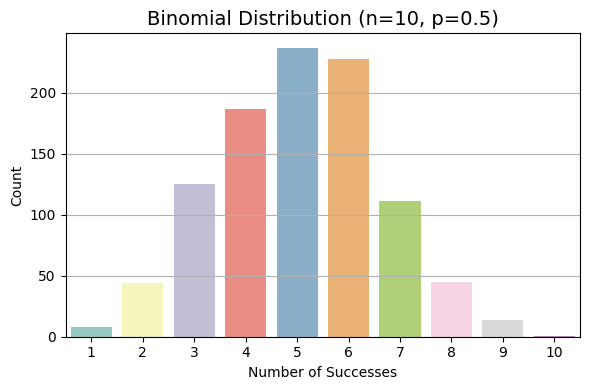

In [49]:
plt.figure(figsize=(6, 4))
sns.countplot(x='binomial', data=df, palette='Set3')
plt.title("Binomial Distribution (n=10, p=0.5)", fontsize=14)
plt.xlabel("Number of Successes")
plt.ylabel("Count")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

### Poission Distribution

/tmp/ipython-input-50-1385591032.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='poisson', data=df, palette='viridis')


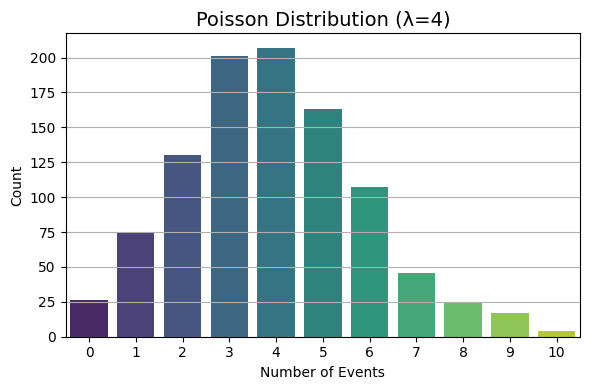

In [50]:
plt.figure(figsize=(6, 4))
sns.countplot(x='poisson', data=df, palette='viridis')
plt.title("Poisson Distribution (λ=4)", fontsize=14)
plt.xlabel("Number of Events")
plt.ylabel("Count")
plt.grid(True, axis='y')
plt.tight_layout()
plt.show()

### Normal Distribution

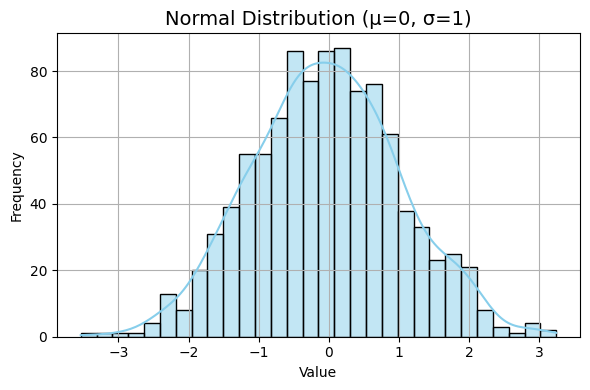

In [51]:
plt.figure(figsize=(6, 4))
sns.histplot(df['normal'], kde=True, color='skyblue', bins=30)
plt.title("Normal Distribution (μ=0, σ=1)", fontsize=14)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

### Exponential Distribution

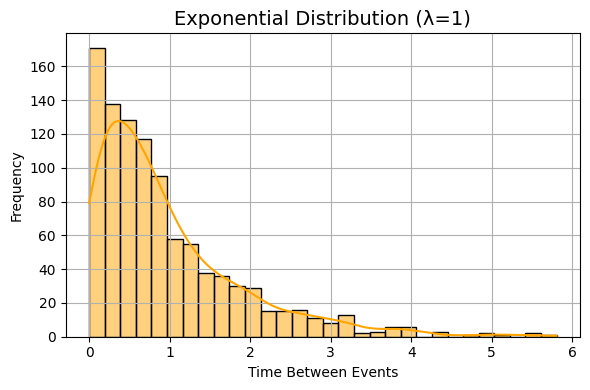

In [52]:
plt.figure(figsize=(6, 4))
sns.histplot(df['exponential'], kde=True, color='orange', bins=30)
plt.title("Exponential Distribution (λ=1)", fontsize=14)
plt.xlabel("Time Between Events")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()

### Uniform Distribution

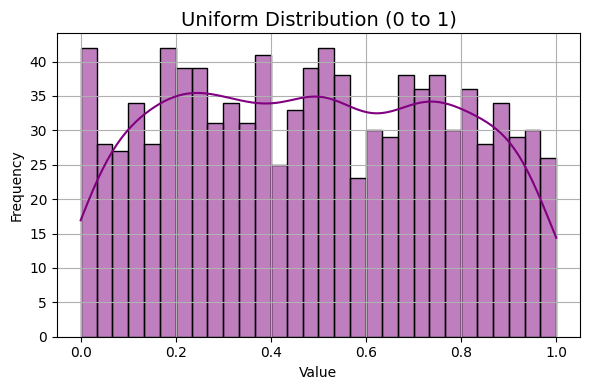

In [53]:
plt.figure(figsize=(6, 4))
sns.histplot(df['uniform'], kde=True, color='purple', bins=30)
plt.title("Uniform Distribution (0 to 1)", fontsize=14)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.show()


# How to Find the Best-Fitting Distribution
### Step-by-Step: How to Find the Best-Fitting Distribution

In [54]:
# Step 0: Load Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm

In [55]:
# Sample: Daily weather data for Delhi (downloaded and hosted on GitHub)
url = 'https://raw.githubusercontent.com/plotly/datasets/master/2016-weather-data-seattle.csv'  # substitute for real GHCN
df = pd.read_csv(url)
print(df.describe())
# We'll focus on daily precipitation (rename as needed)
data = df['Mean_TemperatureC'].replace('T', 0).astype(float) * 25.4  # Convert inches to mm, 'T' is trace rain
data = data[data > 0]  # consider only days with rainfall


       Max_TemperatureC  Mean_TemperatureC  Min_TemperatureC
count      24381.000000       24376.000000      24380.000000
mean          14.944014          11.043485          7.252338
std            7.171926           5.794158          4.913692
min          -18.000000         -12.000000        -17.000000
25%            9.000000           7.000000          4.000000
50%           14.000000          11.000000          7.000000
75%           20.000000          16.000000         11.000000
max           54.000000          31.000000         22.000000


## Visual Inspection (First Look)

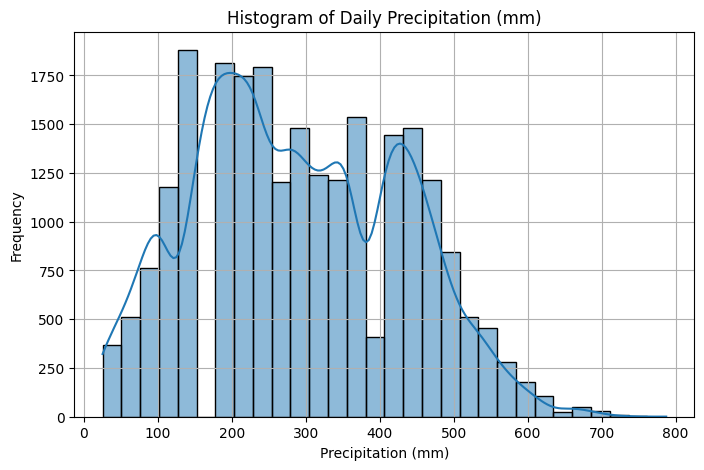

In [56]:
plt.figure(figsize=(8, 5))
sns.histplot(data, kde=True, bins=30)
plt.title("Histogram of Daily Precipitation (mm)")
plt.xlabel("Precipitation (mm)")
plt.ylabel("Frequency")
plt.grid(True)
plt.show()


## Fit Common Distributions

# Fit a few common distributions
distributions = [stats.norm, stats.expon, stats.gamma]
fitted_params = {}

for dist in distributions:
    params = dist.fit(data)
    fitted_params[dist.name] = params
    print(f"{dist.name} params: {params}")


## Goodness-of-Fit Tests

In [60]:
for dist_name, params in fitted_params.items():
    dist = getattr(stats, dist_name)
    stat, p_value = stats.kstest(data, dist_name, args=params)
    print(f"{dist_name} - K-S Test: stat = {stat:.4f}, p = {p_value:.4f}")


norm - K-S Test: stat = 0.0918, p = 0.0000
expon - K-S Test: stat = 0.2456, p = 0.0000
gamma - K-S Test: stat = 0.0858, p = 0.0000


## Q-Q Plot (Quantile-Quantile Plot)

In [ ]:
# Q-Q Plot for best-fit normal distribution (or pick one from results above)
sm.qqplot(data, dist=stats.norm, line='45', fit=True)
plt.title("Q-Q Plot against Normal Distribution")
plt.grid(True)
plt.show()


In [59]:
# You need to install fitter first (pip install fitter)
from fitter import Fitter

f = Fitter(data,
           distributions=['gamma', 'lognorm', 'beta', 'expon', 'norm'],
           timeout=60)
f.fit()
f.summary()


ModuleNotFoundError: No module named 'fitter'

In [58]:
# Fit a few common distributions
distributions = [stats.norm, stats.expon, stats.gamma]
fitted_params = {}

for dist in distributions:
    params = dist.fit(data)
    fitted_params[dist.name] = params
    print(f"{dist.name} params: {params}")

norm params: (np.float64(289.0472335591366), np.float64(138.5287092235831))
expon params: (25.4, 263.6472335591366)
gamma params: (np.float64(18.77723483010975), np.float64(-317.0403823112882), np.float64(32.27553144319876))
